In [1]:
import pandas as pd
import numpy as np


In [2]:
data = pd.read_excel(r"D:\my project\codeit_datascience\data_science\regression\data science\Ecommerce Sales Data.xlsx")
data.head()

,Row ID,Order ID,Year,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013,2013-09-11 00:00:00,2013-12-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,2013,2013-09-11 00:00:00,2013-12-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,2013,6/13/2013,6/17/2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,2012,2012-11-10 00:00:00,10/18/2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,2012,2012-11-10 00:00:00,10/18/2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Year           9994 non-null   int64  
 3   Order Date     9994 non-null   object 
 4   Ship Date      9994 non-null   object 
 5   Ship Mode      9994 non-null   str    
 6   Customer ID    9994 non-null   str    
 7   Customer Name  9994 non-null   str    
 8   Segment        9994 non-null   str    
 9   Country        9994 non-null   str    
 10  City           9994 non-null   str    
 11  State          9994 non-null   str    
 12  Postal Code    9994 non-null   int64  
 13  Region         9994 non-null   str    
 14  Product ID     9994 non-null   str    
 15  Category       9994 non-null   str    
 16  Sub-Category   9994 non-null   str    
 17  Product Name   9994 non-null   str    
 18  Sales          9994

In [5]:
# change 'Order Date' and 'Ship Date' dtype to datetime
data['Order Date']=pd.to_datetime(data['Order Date'])

In [7]:
data['Ship Date']=pd.to_datetime(data['Ship Date'])

In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Year           9994 non-null   int64         
 3   Order Date     9994 non-null   datetime64[us]
 4   Ship Date      9994 non-null   datetime64[us]
 5   Ship Mode      9994 non-null   str           
 6   Customer ID    9994 non-null   str           
 7   Customer Name  9994 non-null   str           
 8   Segment        9994 non-null   str           
 9   Country        9994 non-null   str           
 10  City           9994 non-null   str           
 11  State          9994 non-null   str           
 12  Postal Code    9994 non-null   int64         
 13  Region         9994 non-null   str           
 14  Product ID     9994 non-null   str           
 15  Category       9994 non-null   s

# Resampling Data

In [15]:
data.reset_index(inplace=True)


In [16]:
# grouping data: either daily, weekly, monthly, hourly

# set 'Order Date' as index
# sort data on bais of 'Order Date'
data.sort_values(by='Order Date', inplace=True)

In [18]:
data

,Order Date,Row ID,Order ID,Year,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,2011-01-02,3366,CA-2011-115161,2011,2011-03-02,First Class,LC-17050,Liz Carlisle,Consumer,United States,...,92691,West,FUR-BO-10003966,Furniture,Bookcases,"Sauder Facets Collection Library, Sky Alder Fi...",290.666,2,0.15,3.4196
10,2011-01-03,7949,CA-2011-131009,2011,2011-05-03,Standard Class,SC-20380,Shahid Collister,Consumer,United States,...,79907,Central,FUR-CH-10001270,Furniture,Chairs,Harbour Creations Steel Folding Chair,362.250,6,0.30,0.0000
8,2011-01-03,6549,CA-2011-113880,2011,2011-05-03,Standard Class,VF-21715,Vicky Freymann,Home Office,United States,...,60126,Central,OFF-PA-10003036,Office Supplies,Paper,"Black Print Carbonless 8 1/2"" x 8 1/4"" Rapid M...",17.472,3,0.20,5.6784
7,2011-01-03,5714,US-2011-143707,2011,2011-05-03,Standard Class,HR-14770,Hallie Redmond,Home Office,United States,...,10035,East,TEC-PH-10003655,Technology,Phones,Sannysis Cute Owl Design Soft Skin Case Cover ...,5.940,3,0.00,1.6038
6,2011-01-03,6548,CA-2011-113880,2011,2011-05-03,Standard Class,VF-21715,Vicky Freymann,Home Office,United States,...,60126,Central,FUR-CH-10000863,Furniture,Chairs,Novimex Swivel Fabric Task Chair,634.116,6,0.30,-172.1172
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9988,2014-12-31,907,CA-2014-143259,2014,2015-04-01,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,...,10009,East,FUR-BO-10003441,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Fully Ass...",323.136,4,0.20,12.1176
9989,2014-12-31,908,CA-2014-143259,2014,2015-04-01,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,...,10009,East,TEC-PH-10004774,Technology,Phones,Gear Head AU3700S Headset,90.930,7,0.00,2.7279
9990,2014-12-31,1297,CA-2014-115427,2014,2015-04-01,Standard Class,EB-13975,Erica Bern,Corporate,United States,...,94533,West,OFF-BI-10002103,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",13.904,2,0.20,4.5188
9991,2014-12-31,1298,CA-2014-115427,2014,2015-04-01,Standard Class,EB-13975,Erica Bern,Corporate,United States,...,94533,West,OFF-BI-10004632,Office Supplies,Binders,GBC Binding covers,20.720,2,0.20,6.4750


In [19]:
# set_index() -- 'Order Date'
data.set_index('Order Date', inplace=True)

In [20]:
data.head(2)

,Row ID,Order ID,Year,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
Order Date,,,,,,,,,,,,,,,,,,,,,
2011-01-02,3366,CA-2011-115161,2011,2011-03-02,First Class,LC-17050,Liz Carlisle,Consumer,United States,Mission Viejo,...,92691,West,FUR-BO-10003966,Furniture,Bookcases,"Sauder Facets Collection Library, Sky Alder Fi...",290.666,2,0.15,3.4196
2011-01-03,7949,CA-2011-131009,2011,2011-05-03,Standard Class,SC-20380,Shahid Collister,Consumer,United States,El Paso,...,79907,Central,FUR-CH-10001270,Furniture,Chairs,Harbour Creations Steel Folding Chair,362.250,6,0.30,0.0000


In [24]:
# Get total sales per month
# resample monthly
data.resample('ME')['Sales'].sum()

Order Date
2011-01-31    28484.8060
2011-02-28    13129.9300
2011-03-31    54899.9920
2011-04-30    24401.1320
2011-05-31    30042.7420
2011-06-30    24568.9546
2011-07-31    39811.3800
2011-08-31    38107.4655
2011-09-30    66084.2398
2011-10-31    34547.6610
2011-11-30    62819.1085
2011-12-31    67350.0867
2012-01-31    29087.9304
2012-02-29    20987.8080
2012-03-31    40876.6112
2012-04-30    38056.9685
2012-05-31    30933.7145
2012-06-30    28862.1982
2012-07-31    28730.3760
2012-08-31    50094.5280
2012-09-30    66729.3290
2012-10-31    32025.0750
2012-11-30    50732.3090
2012-12-31    53415.6612
2013-01-31    21998.1470
2013-02-28    41411.8460
2013-03-31    61470.8110
2013-04-30    48654.4390
2013-05-31    66946.5680
2013-06-30    44643.4538
2013-07-31    40454.6170
2013-08-31    45065.8533
2013-09-30    55505.9529
2013-10-31    34980.5330
2013-11-30    72985.8510
2013-12-31    74355.7580
2014-01-31    58016.2488
2014-02-28    44845.3254
2014-03-31    80235.3360
2014-04-30    

In [27]:
# monthly profit --- 'ME' (Monthly end)
data.resample('ME')['Profit'].sum()

Order Date
2011-01-31     4343.1386
2011-02-28     2829.4264
2011-03-31       62.7389
2011-04-30     4653.0309
2011-05-31     3892.5190
2011-06-30     3070.0929
2011-07-31     -336.3935
2011-08-31     2063.1215
2011-09-30    10226.8774
2011-10-31     4063.4142
2011-11-30     6379.3200
2011-12-31     8296.6878
2012-01-31     1229.6376
2012-02-29     2178.8290
2012-03-31     9165.6802
2012-04-30     6132.8819
2012-05-31     2779.3998
2012-06-30     4788.4461
2012-07-31      671.7960
2012-08-31    10112.2771
2012-09-30     9929.3009
2012-10-31     3433.2405
2012-11-30     5582.4023
2012-12-31     5614.7123
2013-01-31     2653.0537
2013-02-28    10637.7014
2013-03-31    12247.4457
2013-04-30     3415.0320
2013-05-31    12794.7741
2013-06-30     5470.9401
2013-07-31     3608.4433
2013-08-31     5478.6019
2013-09-30     3542.5733
2013-10-31     6646.3720
2013-11-30     2755.4642
2013-12-31    12476.5291
2014-01-31     9519.7930
2014-02-28     4764.5993
2014-03-31    14047.2219
2014-04-30    

In [28]:
# monthly items sold -- 'MS'(Monthly start)
data.resample('MS')['Quantity'].sum()

Order Date
2011-01-01     502
2011-02-01     315
2011-03-01     616
2011-04-01     460
2011-05-01     565
2011-06-01     458
2011-07-01     611
2011-08-01     623
2011-09-01     900
2011-10-01     558
2011-11-01     964
2011-12-01    1009
2012-01-01     327
2012-02-01     404
2012-03-01     570
2012-04-01     552
2012-05-01     697
2012-06-01     539
2012-07-01     526
2012-08-01     706
2012-09-01    1041
2012-10-01     593
2012-11-01    1138
2012-12-01     886
2013-01-01     384
2013-02-01     509
2013-03-01     660
2013-04-01     760
2013-05-01     965
2013-06-01     871
2013-07-01     837
2013-08-01     783
2013-09-01    1068
2013-10-01     746
2013-11-01    1220
2013-12-01    1007
2014-01-01     837
2014-02-01     703
2014-03-01    1247
2014-04-01     931
2014-05-01     917
2014-06-01     902
2014-07-01     798
2014-08-01     995
2014-09-01    1293
2014-10-01    1184
2014-11-01    1466
2014-12-01    1230
Freq: MS, Name: Quantity, dtype: int64

In [29]:
# Weekly 
data.resample('W')['Sales'].sum()

Order Date
2011-01-02      290.6660
2011-01-09     8810.3470
2011-01-16    14126.8850
2011-01-23     3442.5400
2011-01-30     1573.8680
                 ...    
2014-12-07     7294.2850
2014-12-14    11492.8510
2014-12-21    13010.6350
2014-12-28    21433.9480
2015-01-04     5286.6748
Freq: W-SUN, Name: Sales, Length: 210, dtype: float64

In [31]:
#yearly end
data.resample('YE')['Sales'].sum()

Order Date
2011-12-31    484247.4981
2012-12-31    470532.5090
2013-12-31    608473.8300
2014-12-31    733947.0232
Freq: YE-DEC, Name: Sales, dtype: float64

In [32]:
# yearly start
data.resample('YS')['Profit'].sum()

Order Date
2011-01-01    49543.9741
2012-01-01    61618.6037
2013-01-01    81726.9308
2014-01-01    93507.5131
Freq: YS-JAN, Name: Profit, dtype: float64

# Rolling window

In [33]:
# similar to quarterly report


In [35]:
# monthly sales data
msales_data=data.resample('ME')['Sales'].sum()

In [49]:
monthly_sales = pd.DataFrame(msales_data)

In [50]:
monthly_sales.head()

,Sales
Order Date,
2011-01-31,28484.806
2011-02-28,13129.930
2011-03-31,54899.992
2011-04-30,24401.132
2011-05-31,30042.742


In [51]:
monthly_sales.ndim

2

In [54]:
# get 'Sales' mean() of 7 months 
monthly_sales['new_values']=monthly_sales['Sales'].rolling(window=7).mean()

In [55]:
monthly_sales

,Sales,new_values
Order Date,,
2011-01-31,28484.8060,NaN
2011-02-28,13129.9300,NaN
2011-03-31,54899.9920,NaN
2011-04-30,24401.1320,NaN
2011-05-31,30042.7420,NaN
2011-06-30,24568.9546,NaN
2011-07-31,39811.3800,30762.705229
2011-08-31,38107.4655,32137.370871
2011-09-30,66084.2398,39702.272271


In [58]:
# get 'Sales' quaterly report of sum
monthly_sales['quater_sales']=monthly_sales['Sales'].rolling(window=3).sum()

In [59]:
monthly_sales

,Sales,new_values,quater_sales
Order Date,,,
2011-01-31,28484.8060,NaN,NaN
2011-02-28,13129.9300,NaN,NaN
2011-03-31,54899.9920,NaN,96514.7280
2011-04-30,24401.1320,NaN,92431.0540
2011-05-31,30042.7420,NaN,109343.8660
2011-06-30,24568.9546,NaN,79012.8286
2011-07-31,39811.3800,30762.705229,94423.0766
2011-08-31,38107.4655,32137.370871,102487.8001
2011-09-30,66084.2398,39702.272271,144003.0853


In [60]:
# weekly data
data.resample('W')['Sales'].sum()

Order Date
2011-01-02      290.6660
2011-01-09     8810.3470
2011-01-16    14126.8850
2011-01-23     3442.5400
2011-01-30     1573.8680
                 ...    
2014-12-07     7294.2850
2014-12-14    11492.8510
2014-12-21    13010.6350
2014-12-28    21433.9480
2015-01-04     5286.6748
Freq: W-SUN, Name: Sales, Length: 210, dtype: float64

In [63]:
weekly_sales=data.resample('W')['Sales'].sum()

In [64]:
df_weekly_sales = pd.DataFrame(weekly_sales)
df_weekly_sales.head()

,Sales
Order Date,
2011-01-02,290.666
2011-01-09,8810.347
2011-01-16,14126.885
2011-01-23,3442.540
2011-01-30,1573.868


In [66]:
# rolling window 3 -- 3 weeks sales data sum
df_weekly_sales['3 weeks'] = df_weekly_sales['Sales'].rolling(window=3).sum()
df_weekly_sales

,Sales,3 weeks
Order Date,,
2011-01-02,290.6660,NaN
2011-01-09,8810.3470,NaN
2011-01-16,14126.8850,23227.8980
2011-01-23,3442.5400,26379.7720
2011-01-30,1573.8680,19143.2930
...,...,...
2014-12-07,7294.2850,63721.7648
2014-12-14,11492.8510,42637.3010
2014-12-21,13010.6350,31797.7710


In [77]:
# rolling window 5 -- 5 weeks Max sales data
df_weekly_sales['5 weeks']=df_weekly_sales['Sales'].rolling(window=5).sum()
df_weekly_sales

,Sales,3 weeks,5 weeks
Order Date,,,
2011-01-02,290.6660,NaN,NaN
2011-01-09,8810.3470,NaN,NaN
2011-01-16,14126.8850,23227.8980,NaN
2011-01-23,3442.5400,26379.7720,NaN
2011-01-30,1573.8680,19143.2930,28244.3060
...,...,...,...
2014-12-07,7294.2850,63721.7648,91991.6480
2014-12-14,11492.8510,42637.3010,94273.7450
2014-12-21,13010.6350,31797.7710,88225.2508


In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='Order Date', ylabel='Sales'>

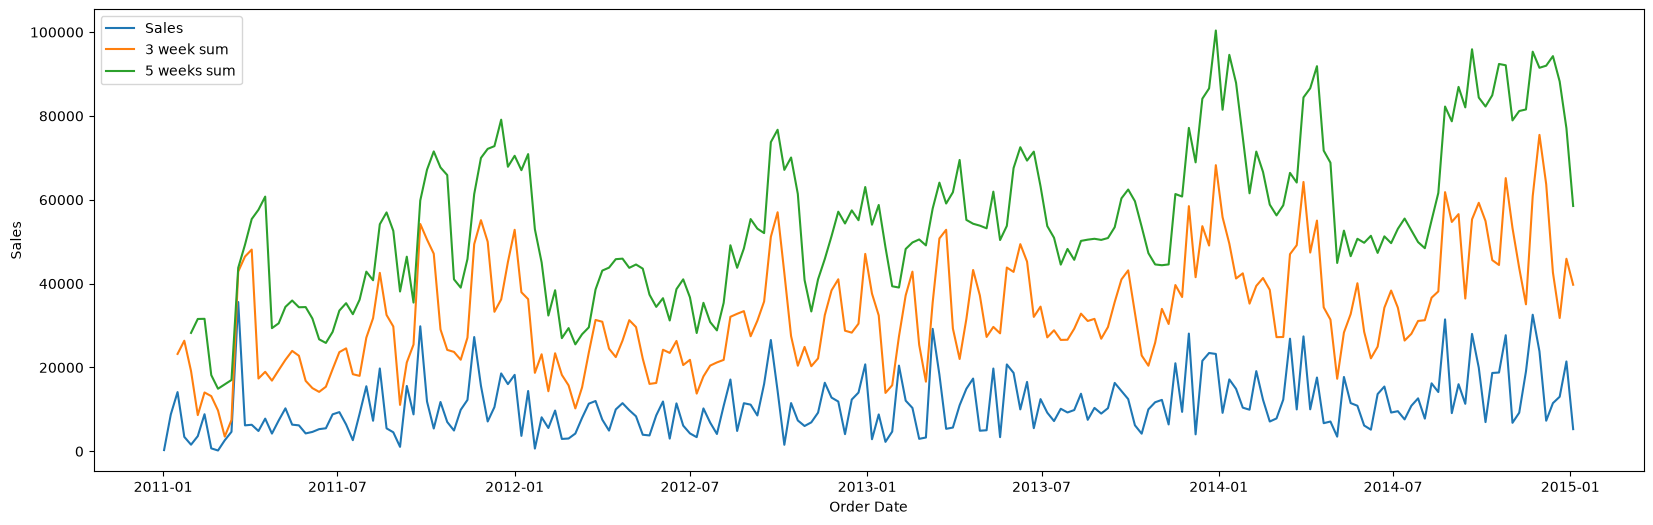

In [78]:
plt.figure(figsize=(20,6))
sns.lineplot(x='Order Date', y='Sales', data=df_weekly_sales, label='Sales')
sns.lineplot(x='Order Date', y='3 weeks', data=df_weekly_sales, label='3 week sum')
sns.lineplot(x='Order Date', y='5 weeks', data=df_weekly_sales, label='5 weeks sum')

# Shifting

In [84]:
# Moving your data forward or backward
monthly_sales.head()

,Sales,new_values,quater_sales
Order Date,,,
2011-01-31,28484.806,NaN,NaN
2011-02-28,13129.930,NaN,NaN
2011-03-31,54899.992,NaN,96514.728
2011-04-30,24401.132,NaN,92431.054
2011-05-31,30042.742,NaN,109343.866


In [86]:
monthly_sales.drop(columns=['new_values','quater_sales'], inplace=True)

In [87]:
monthly_sales.head()

,Sales
Order Date,
2011-01-31,28484.806
2011-02-28,13129.930
2011-03-31,54899.992
2011-04-30,24401.132
2011-05-31,30042.742


In [88]:
# shifting current month sales to next month
monthly_sales['Sales Previous Month'] = monthly_sales['Sales'].shift(1)

In [89]:
monthly_sales

,Sales,Sales Previous Month
Order Date,,
2011-01-31,28484.8060,NaN
2011-02-28,13129.9300,28484.8060
2011-03-31,54899.9920,13129.9300
2011-04-30,24401.1320,54899.9920
2011-05-31,30042.7420,24401.1320
2011-06-30,24568.9546,30042.7420
2011-07-31,39811.3800,24568.9546
2011-08-31,38107.4655,39811.3800
2011-09-30,66084.2398,38107.4655


<Axes: xlabel='Order Date', ylabel='Sales'>

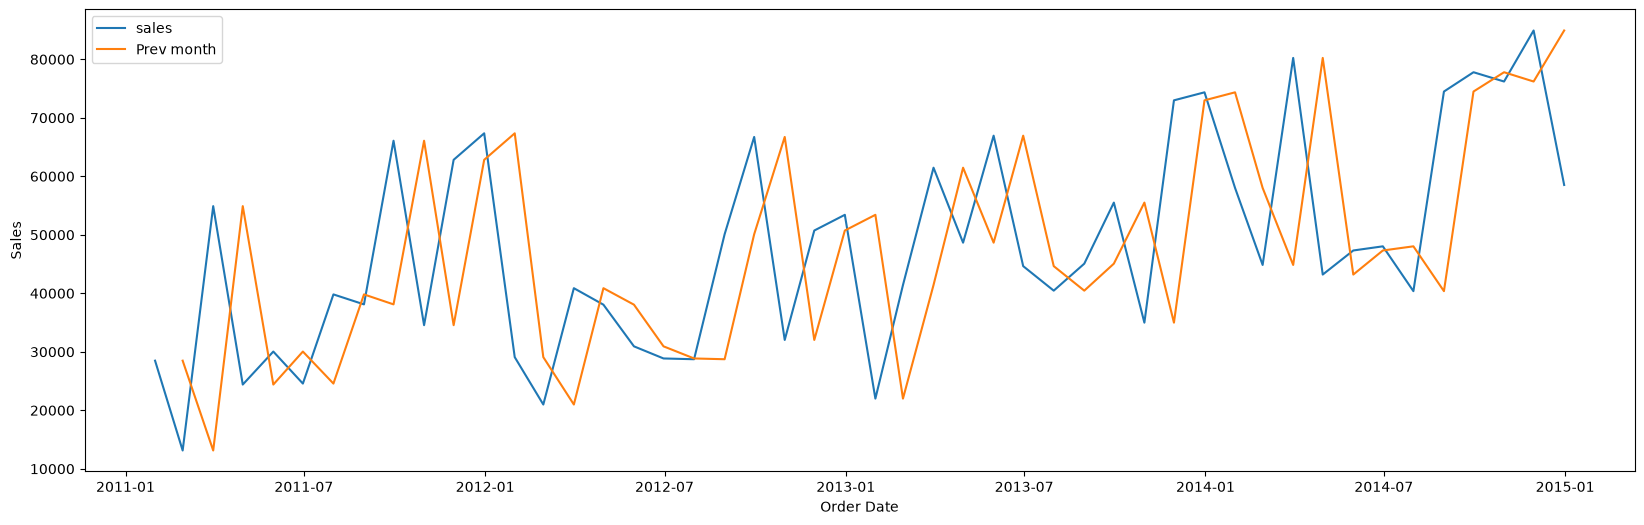

In [94]:
plt.figure(figsize=(20,6))
sns.lineplot(x='Order Date', y='Sales' , data=monthly_sales, label='sales')
sns.lineplot(x='Order Date', y='Sales Previous Month', data=monthly_sales, label='Prev month')

In [96]:
# find difference 
monthly_sales['monthly_diff']=monthly_sales['Sales'] - monthly_sales['Sales Previous Month']

In [97]:
monthly_sales

,Sales,Sales Previous Month,monthly_diff
Order Date,,,
2011-01-31,28484.8060,NaN,NaN
2011-02-28,13129.9300,28484.8060,-15354.8760
2011-03-31,54899.9920,13129.9300,41770.0620
2011-04-30,24401.1320,54899.9920,-30498.8600
2011-05-31,30042.7420,24401.1320,5641.6100
2011-06-30,24568.9546,30042.7420,-5473.7874
2011-07-31,39811.3800,24568.9546,15242.4254
2011-08-31,38107.4655,39811.3800,-1703.9145
2011-09-30,66084.2398,38107.4655,27976.7743


<Axes: xlabel='Order Date', ylabel='Sales'>

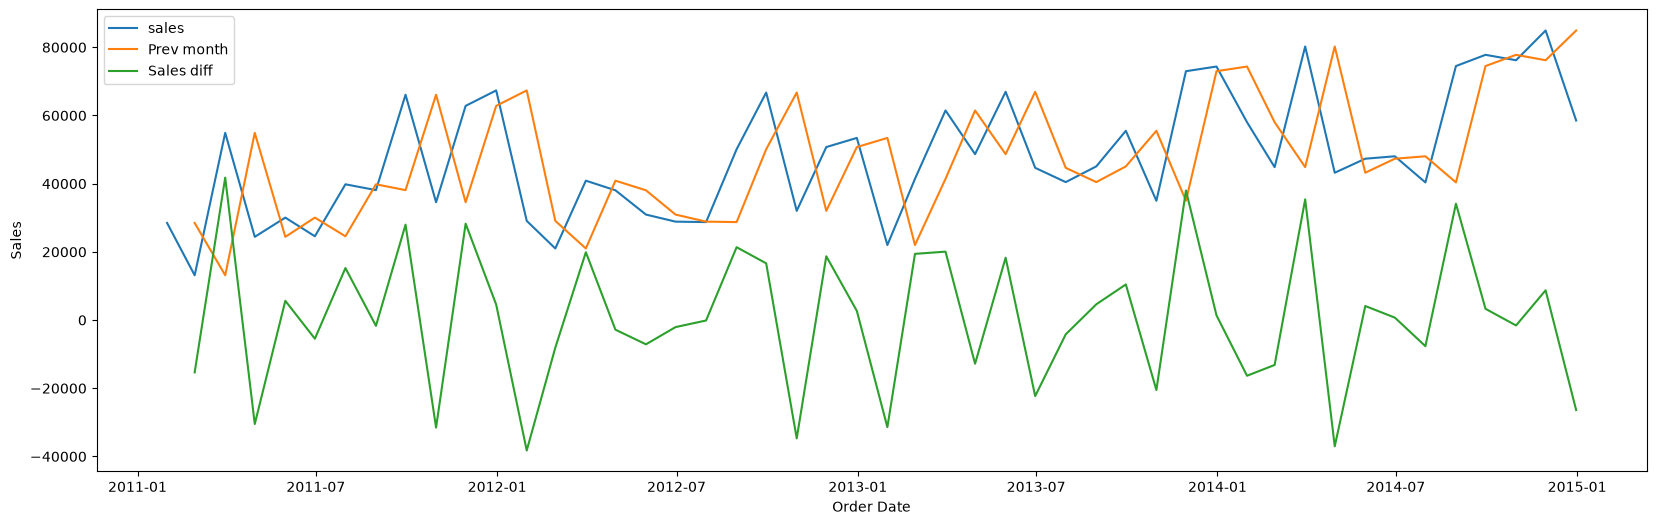

In [98]:
plt.figure(figsize=(20,6))
sns.lineplot(x='Order Date', y='Sales' , data=monthly_sales, label='sales')
sns.lineplot(x='Order Date', y='Sales Previous Month', data=monthly_sales, label='Prev month')
sns.lineplot(x='Order Date', y='monthly_diff', data=monthly_sales, label='Sales diff')

In [99]:
data.head(2)

,Row ID,Order ID,Year,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
Order Date,,,,,,,,,,,,,,,,,,,,,
2011-01-02,3366,CA-2011-115161,2011,2011-03-02,First Class,LC-17050,Liz Carlisle,Consumer,United States,Mission Viejo,...,92691,West,FUR-BO-10003966,Furniture,Bookcases,"Sauder Facets Collection Library, Sky Alder Fi...",290.666,2,0.15,3.4196
2011-01-03,7949,CA-2011-131009,2011,2011-05-03,Standard Class,SC-20380,Shahid Collister,Consumer,United States,El Paso,...,79907,Central,FUR-CH-10001270,Furniture,Chairs,Harbour Creations Steel Folding Chair,362.250,6,0.30,0.0000


In [101]:
data = data[['Sales','Profit']]

In [102]:
data

,Sales,Profit
Order Date,,
2011-01-02,290.666,3.4196
2011-01-03,362.250,0.0000
2011-01-03,17.472,5.6784
2011-01-03,5.940,1.6038
2011-01-03,634.116,-172.1172
...,...,...
2014-12-31,323.136,12.1176
2014-12-31,90.930,2.7279
2014-12-31,13.904,4.5188


In [103]:
weekly_sales = data.resample('W')['Profit'].sum()
weekly_sales

Order Date
2011-01-02       3.4196
2011-01-09    1621.6275
2011-01-16    2224.8399
2011-01-23     301.0276
2011-01-30     180.5738
                ...    
2014-12-07     664.9016
2014-12-14    1568.8432
2014-12-21    1607.4239
2014-12-28    3768.5680
2015-01-04     999.0891
Freq: W-SUN, Name: Profit, Length: 210, dtype: float64

In [105]:
weekly_sales = weekly_sales.reset_index()

In [106]:
weekly_sales

,Order Date,Profit
0,2011-01-02,3.4196
1,2011-01-09,1621.6275
2,2011-01-16,2224.8399
3,2011-01-23,301.0276
4,2011-01-30,180.5738
...,...,...
205,2014-12-07,664.9016
206,2014-12-14,1568.8432
207,2014-12-21,1607.4239
208,2014-12-28,3768.5680


In [107]:
weekly_sales['lag 1']= weekly_sales['Profit'].shift(1)

In [108]:
weekly_sales

,Order Date,Profit,lag 1
0,2011-01-02,3.4196,NaN
1,2011-01-09,1621.6275,3.4196
2,2011-01-16,2224.8399,1621.6275
3,2011-01-23,301.0276,2224.8399
4,2011-01-30,180.5738,301.0276
...,...,...,...
205,2014-12-07,664.9016,3382.2059
206,2014-12-14,1568.8432,664.9016
207,2014-12-21,1607.4239,1568.8432
208,2014-12-28,3768.5680,1607.4239


In [109]:
weekly_sales['lag 2']=weekly_sales['Profit'].shift(2)

In [110]:
weekly_sales

,Order Date,Profit,lag 1,lag 2
0,2011-01-02,3.4196,NaN,NaN
1,2011-01-09,1621.6275,3.4196,NaN
2,2011-01-16,2224.8399,1621.6275,3.4196
3,2011-01-23,301.0276,2224.8399,1621.6275
4,2011-01-30,180.5738,301.0276,2224.8399
...,...,...,...,...
205,2014-12-07,664.9016,3382.2059,5887.9832
206,2014-12-14,1568.8432,664.9016,3382.2059
207,2014-12-21,1607.4239,1568.8432,664.9016
208,2014-12-28,3768.5680,1607.4239,1568.8432


In [111]:
# is there any relation between monthly sales
monthly_sales

,Sales,Sales Previous Month,monthly_diff
Order Date,,,
2011-01-31,28484.8060,NaN,NaN
2011-02-28,13129.9300,28484.8060,-15354.8760
2011-03-31,54899.9920,13129.9300,41770.0620
2011-04-30,24401.1320,54899.9920,-30498.8600
2011-05-31,30042.7420,24401.1320,5641.6100
2011-06-30,24568.9546,30042.7420,-5473.7874
2011-07-31,39811.3800,24568.9546,15242.4254
2011-08-31,38107.4655,39811.3800,-1703.9145
2011-09-30,66084.2398,38107.4655,27976.7743


In [112]:
monthly_sales[['Sales','Sales Previous Month']].corr()

,Sales,Sales Previous Month
Sales,1.000000,0.334247
Sales Previous Month,0.334247,1.000000


<Axes: >

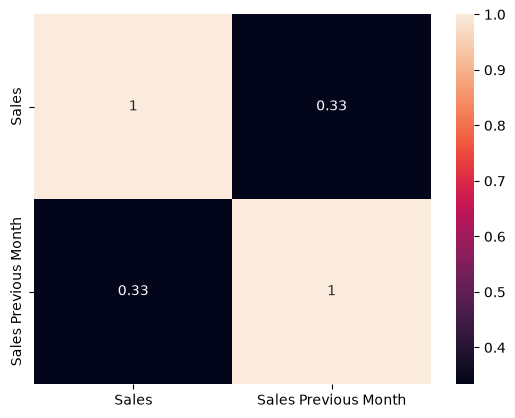

In [113]:
sns.heatmap(monthly_sales[['Sales','Sales Previous Month']].corr(), annot=True)

<Axes: xlabel='Sales', ylabel='Sales Previous Month'>

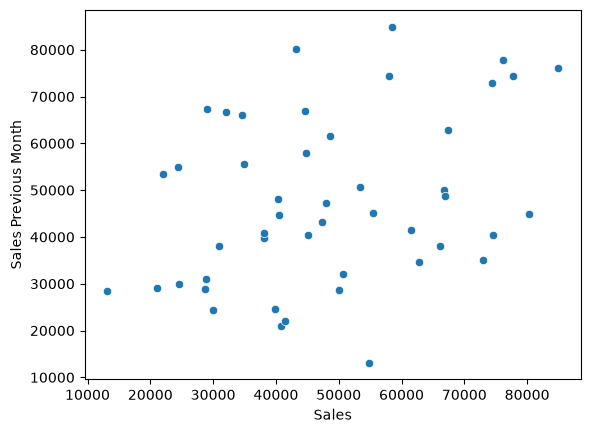

In [114]:
# check outliers
sns.scatterplot(x='Sales',y='Sales Previous Month', data=monthly_sales)

<Axes: ylabel='Sales'>

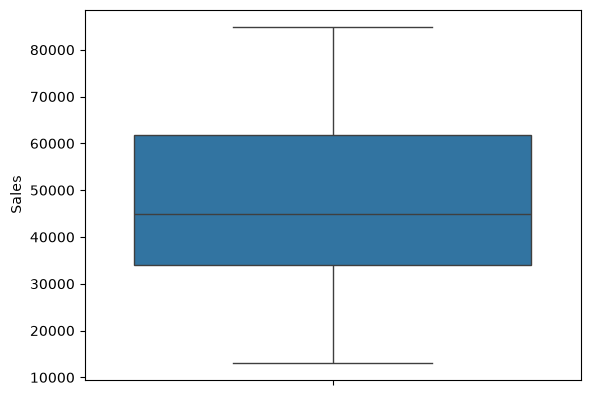

In [115]:
sns.boxplot(y='Sales', data=monthly_sales)

<Axes: ylabel='Sales Previous Month'>

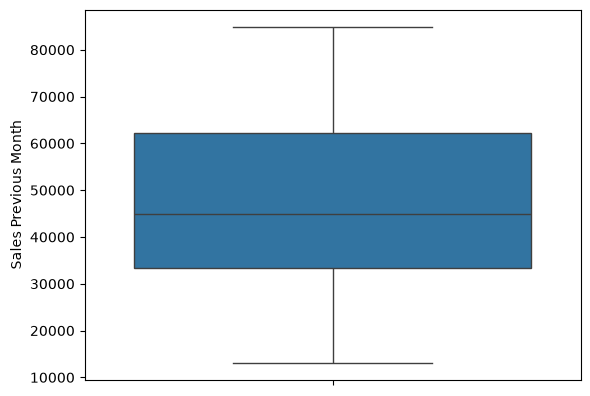

In [116]:
sns.boxplot(y='Sales Previous Month', data=monthly_sales)

In [117]:
monthly_sales

,Sales,Sales Previous Month,monthly_diff
Order Date,,,
2011-01-31,28484.8060,NaN,NaN
2011-02-28,13129.9300,28484.8060,-15354.8760
2011-03-31,54899.9920,13129.9300,41770.0620
2011-04-30,24401.1320,54899.9920,-30498.8600
2011-05-31,30042.7420,24401.1320,5641.6100
2011-06-30,24568.9546,30042.7420,-5473.7874
2011-07-31,39811.3800,24568.9546,15242.4254
2011-08-31,38107.4655,39811.3800,-1703.9145
2011-09-30,66084.2398,38107.4655,27976.7743


In [119]:
monthly_sales['pg'] = (monthly_sales['monthly_diff'] / monthly_sales['Sales'])*100

In [120]:
monthly_sales

,Sales,Sales Previous Month,monthly_diff,pg
Order Date,,,,
2011-01-31,28484.8060,NaN,NaN,NaN
2011-02-28,13129.9300,28484.8060,-15354.8760,-116.945604
2011-03-31,54899.9920,13129.9300,41770.0620,76.083913
2011-04-30,24401.1320,54899.9920,-30498.8600,-124.989529
2011-05-31,30042.7420,24401.1320,5641.6100,18.778612
2011-06-30,24568.9546,30042.7420,-5473.7874,-22.279285
2011-07-31,39811.3800,24568.9546,15242.4254,38.286604
2011-08-31,38107.4655,39811.3800,-1703.9145,-4.471340
2011-09-30,66084.2398,38107.4655,27976.7743,42.335017


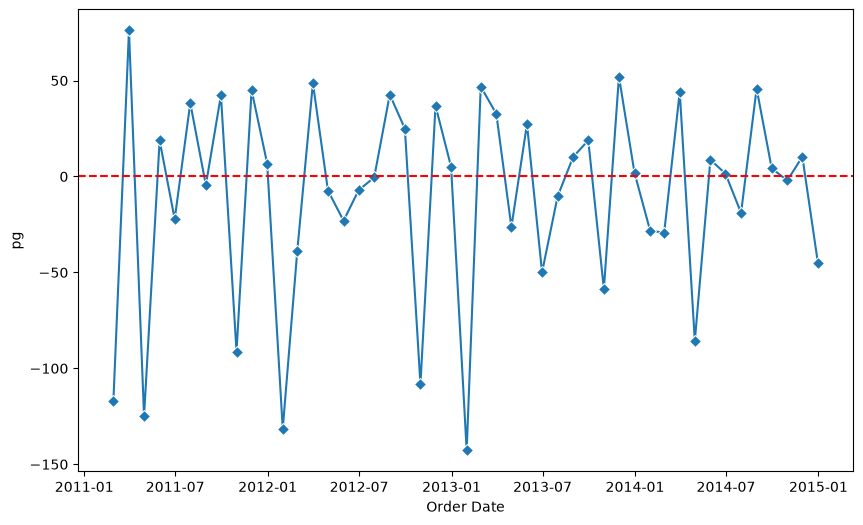

In [124]:
plt.figure(figsize=(10,6))
sns.lineplot(x='Order Date', y='pg', data=monthly_sales, marker='D')
plt.axhline(0, color='red', linestyle='--')

In [125]:
monthly_sales['pg'].agg(['min','max','mean'])

min    -142.818912
max      76.083913
mean    -10.306156
Name: pg, dtype: float64

In [130]:
monthly_sales.head(2)

,Sales,Sales Previous Month,monthly_diff,pg
Order Date,,,,
2011-01-31,28484.806,NaN,NaN,NaN
2011-02-28,13129.930,28484.806,-15354.876,-116.945604


In [133]:
monthly_sales = monthly_sales.reset_index()

In [134]:
monthly_sales

,Order Date,Sales,Sales Previous Month,monthly_diff,pg
0,2011-01-31,28484.8060,NaN,NaN,NaN
1,2011-02-28,13129.9300,28484.8060,-15354.8760,-116.945604
2,2011-03-31,54899.9920,13129.9300,41770.0620,76.083913
3,2011-04-30,24401.1320,54899.9920,-30498.8600,-124.989529
4,2011-05-31,30042.7420,24401.1320,5641.6100,18.778612
5,2011-06-30,24568.9546,30042.7420,-5473.7874,-22.279285
6,2011-07-31,39811.3800,24568.9546,15242.4254,38.286604
7,2011-08-31,38107.4655,39811.3800,-1703.9145,-4.471340
8,2011-09-30,66084.2398,38107.4655,27976.7743,42.335017
9,2011-10-31,34547.6610,66084.2398,-31536.5788,-91.284266


In [135]:
# get month name
monthly_sales['month name']=monthly_sales['Order Date'].dt.month_name()

In [136]:
monthly_sales

,Order Date,Sales,Sales Previous Month,monthly_diff,pg,month name
0,2011-01-31,28484.8060,NaN,NaN,NaN,January
1,2011-02-28,13129.9300,28484.8060,-15354.8760,-116.945604,February
2,2011-03-31,54899.9920,13129.9300,41770.0620,76.083913,March
3,2011-04-30,24401.1320,54899.9920,-30498.8600,-124.989529,April
4,2011-05-31,30042.7420,24401.1320,5641.6100,18.778612,May
5,2011-06-30,24568.9546,30042.7420,-5473.7874,-22.279285,June
6,2011-07-31,39811.3800,24568.9546,15242.4254,38.286604,July
7,2011-08-31,38107.4655,39811.3800,-1703.9145,-4.471340,August
8,2011-09-30,66084.2398,38107.4655,27976.7743,42.335017,September
9,2011-10-31,34547.6610,66084.2398,-31536.5788,-91.284266,October


In [137]:
def find(value):
    if value <=0:
        return 'Loss'
    else:
        return 'Profit'

In [138]:
monthly_sales['PL'] = monthly_sales['pg'].apply(find)

In [139]:
monthly_sales

,Order Date,Sales,Sales Previous Month,monthly_diff,pg,month name,PL
0,2011-01-31,28484.8060,NaN,NaN,NaN,January,Profit
1,2011-02-28,13129.9300,28484.8060,-15354.8760,-116.945604,February,Loss
2,2011-03-31,54899.9920,13129.9300,41770.0620,76.083913,March,Profit
3,2011-04-30,24401.1320,54899.9920,-30498.8600,-124.989529,April,Loss
4,2011-05-31,30042.7420,24401.1320,5641.6100,18.778612,May,Profit
5,2011-06-30,24568.9546,30042.7420,-5473.7874,-22.279285,June,Loss
6,2011-07-31,39811.3800,24568.9546,15242.4254,38.286604,July,Profit
7,2011-08-31,38107.4655,39811.3800,-1703.9145,-4.471340,August,Loss
8,2011-09-30,66084.2398,38107.4655,27976.7743,42.335017,September,Profit
9,2011-10-31,34547.6610,66084.2398,-31536.5788,-91.284266,October,Loss


In [140]:
monthly_sales['PL'].value_counts()

PL
Profit    25
Loss      23
Name: count, dtype: int64

In [142]:
pd.set_option('display.float_format','{:,.0f}'.format)


In [143]:
monthly_sales.groupby('PL')['Sales'].sum()

PL
Loss       855,324
Profit   1,441,877
Name: Sales, dtype: float64